# CodeSoft Data Science Internship
## Task 4: Sales Prediction Using Python

### Objective
The objective of this project is to build a Machine Learning model that predicts sales based on advertising expenditure on TV, Radio, and Newspaper.

In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("advertising.csv")

In [4]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [5]:
df.shape

(200, 4)

# Exploring the Dataset

In this section, we will understand the structure of the dataset, check for missing values, and view basic statistical information.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [7]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [8]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


# Data Visualization

In this section, we will visualize the data to understand how advertising on TV, Radio, and Newspaper affects Sales.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

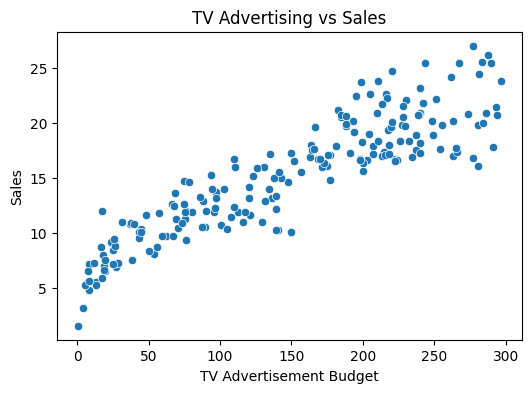

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertisement Budget")
plt.ylabel("Sales")
plt.show()

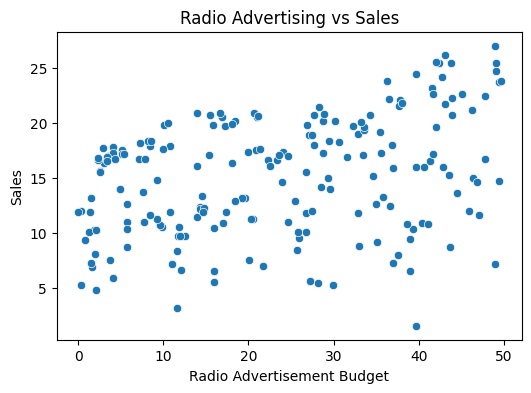

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertisement Budget")
plt.ylabel("Sales")
plt.show()

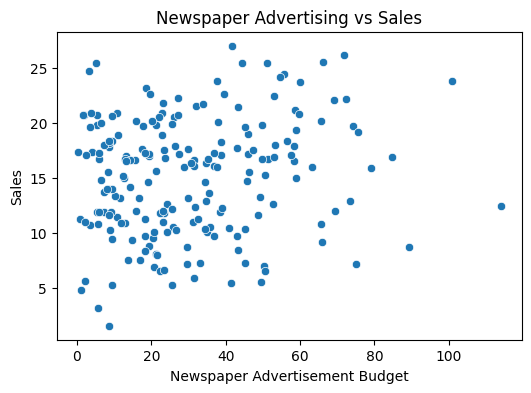

In [12]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Newspaper', y='Sales', data=df)
plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertisement Budget")
plt.ylabel("Sales")
plt.show()

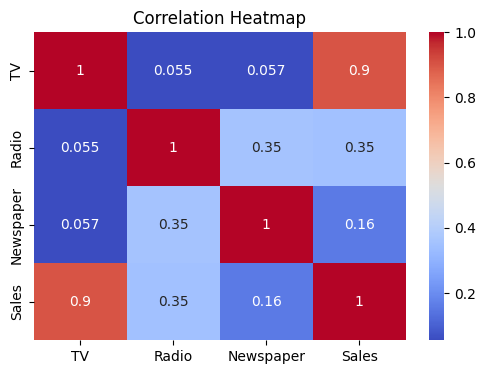

In [13]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Preparing the Data

In this step, we separate the input features (TV, Radio, Newspaper) and the target variable (Sales). This data will be used to train the Machine Learning model.

In [14]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [15]:
X.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [16]:
y.head()

,Sales
0,22.1
1,10.4
2,12.0
3,16.5
4,17.9


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (160, 3)
Testing Data: (40, 3)


# Training the Linear Regression Model

In this step, we train a Linear Regression model using the training data. The model learns the relationship between advertising expenditure and sales.

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
model = LinearRegression()

In [22]:
model.fit(X_train, y_train)

LinearRegression()

In [23]:
y_pred = model.predict(X_test)

In [25]:
print("Predicted Sales:")
print(y_pred[:10])

Predicted Sales:
[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475]


# Model Evaluation

In this step, we evaluate the performance of the Linear Regression model using different evaluation metrics.

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [27]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [28]:
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.2748262109549338
Mean Squared Error (MSE): 2.9077569102710896
R² Score: 0.9059011844150826


# Actual vs Predicted Sales

This graph compares the actual sales values with the sales predicted by the Linear Regression model. If the predicted values are close to the actual values, it indicates that the model performs well.

In [29]:
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,16.9,17.034772
1,22.4,20.409740
2,21.4,23.723989
3,7.3,9.272785
4,24.7,21.682719
5,12.6,12.569402
6,22.3,21.081195
7,8.4,8.690350
8,16.5,17.237013
9,16.1,16.666575


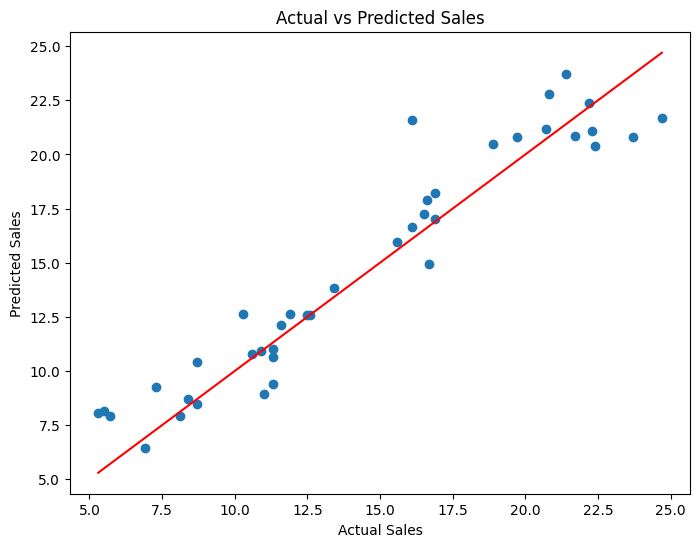

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

# Conclusion

In this project, we built a Sales Prediction model using Linear Regression.

We analyzed the relationship between TV, Radio, and Newspaper advertising with Sales using data visualization and a correlation heatmap. The analysis showed that TV advertising has the strongest positive relationship with sales.

The dataset was divided into training and testing sets, and a Linear Regression model was trained to predict sales. The model achieved a high R² Score, indicating that it can predict sales accurately.

This project demonstrates how Machine Learning can help businesses estimate future sales based on advertising expenditure and make better marketing decisions.

# Future Improvements

- Use larger real-world datasets.
- Try advanced Machine Learning algorithms such as Random Forest and XGBoost.
- Perform feature engineering to improve prediction accuracy.
- Deploy the model as a web application using Streamlit or Flask.